# Chi-Square Test

This notebook demonstrates the **Chi-Square Goodness-of-Fit Test**.

Topics covered:

- Categorical data
- Observed vs expected distributions
- Expected values
- Chi-Square statistic
- Degrees of freedom
- Critical value
- Hypothesis testing
- Decision making
- Python implementation

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# 1. Observed vs Expected Distribution

The Chi-Square Goodness-of-Fit Test compares:

$$
\text{Observed Distribution}
\quad\text{vs}\quad
\text{Expected Distribution}
$$

The observed values come from the sample.

The expected values come from the theoretical distribution.

In [2]:
# Bike color example

categories = ["Yellow", "Red", "Orange"]

observed = np.array([22, 17, 59])

print("Categories:", categories)
print("Observed values:", observed)
print("Total:", observed.sum())

Categories: ['Yellow', 'Red', 'Orange']
Observed values: [22 17 59]
Total: 98


In [3]:
# The theory says each category should contain 1/3 of the observations.

total = observed.sum()

expected = np.array([
    total / 3,
    total / 3,
    total / 3
])

print("Expected values:", expected)
print("Expected total:", expected.sum())

Expected values: [32.66666667 32.66666667 32.66666667]
Expected total: 98.0


In [4]:
# Compare observed and expected values

for category, obs, exp in zip(categories, observed, expected):
    print(f"{category}: Observed = {obs}, Expected = {exp:.2f}")

Yellow: Observed = 22, Expected = 32.67
Red: Observed = 17, Expected = 32.67
Orange: Observed = 59, Expected = 32.67


# 2. Left-Handed Students Example

A science class contains:

$$
75
$$

students.

There are:

- 11 left-handed students
- 64 right-handed students

The theory states that **12% of people are left-handed**.

We want to determine whether the observed distribution fits this theory.

In [5]:
total_students = 75

observed_left = 11
observed_right = total_students - observed_left

observed = np.array([
    observed_left,
    observed_right
])

print("Observed values:", observed)
print("Total:", observed.sum())

Observed values: [11 64]
Total: 75


In [6]:
# Calculate expected values

left_handed_proportion = 0.12

expected_left = left_handed_proportion * total_students
expected_right = total_students - expected_left

expected = np.array([
    expected_left,
    expected_right
])

print("Expected values:", expected)

Expected values: [ 9. 66.]


In [8]:
# Calculate the Chi-Square statistic manually

chi_square = np.sum((observed - expected) ** 2 / expected)

print("Chi-Square statistic:", chi_square)

Chi-Square statistic: 0.505050505050505


For the left-handed student example:

Observed distribution:

$$
(11,64)
$$

Expected distribution:

$$
(9,66)
$$

The Chi-Square statistic measures the overall difference between these
observed and expected values.

# 3. Chi-Square Hypothesis Testing

Now consider the 2010 vs 2020 weight-distribution problem.

### 2010 Theoretical Distribution

| Weight Category | Population |
|---|---:|
| Less than 50 kg | 20% |
| 50–75 kg | 30% |
| Greater than 75 kg | 50% |

### 2020 Observed Sample

Sample size:

$$
n=500
$$

| Weight Category | Observed |
|---|---:|
| Less than 50 kg | 140 |
| 50–75 kg | 160 |
| Greater than 75 kg | 200 |

Significance level:

$$
\alpha=0.05
$$

In [9]:
# Observed 2020 data

observed = np.array([140, 160, 200])

# 2010 theoretical proportions
expected_proportions = np.array([0.20, 0.30, 0.50])

# Total sample size
n = observed.sum()

print("Sample size:", n)
print("Observed values:", observed)
print("Expected proportions:", expected_proportions)

Sample size: 500
Observed values: [140 160 200]
Expected proportions: [0.2 0.3 0.5]


In [10]:
# Calculate expected values

expected = expected_proportions * n

print("Expected values:", expected)
print("Expected total:", expected.sum())

Expected values: [100. 150. 250.]
Expected total: 500.0


# 4. Hypotheses

### Null Hypothesis

$$
H_0:\text{The 2020 distribution is the same as the 2010 distribution}
$$

### Alternative Hypothesis

$$
H_1:\text{The 2020 distribution has changed}
$$

Significance level:

$$
\alpha=0.05
$$

# 5. Degrees of Freedom

For the Chi-Square Goodness-of-Fit Test:

$$
df=k-1
$$

There are three categories:

$$
k=3
$$

Therefore:

$$
df=3-1=2
$$

In [11]:
# Calculate degrees of freedom

k = len(observed)

df = k - 1

print("Number of categories:", k)
print("Degrees of freedom:", df)

Number of categories: 3
Degrees of freedom: 2


# 6. Chi-Square Test Statistic

The formula is:

$$
\chi^2=
\sum
\frac{(O-E)^2}{E}
$$

Where:

- $O$ = Observed value
- $E$ = Expected value

In [12]:
# Calculate each category's contribution

contributions = (observed - expected) ** 2 / expected

for i, contribution in enumerate(contributions):
    print(
        f"Category {i + 1}: "
        f"{contribution:.2f}"
    )

chi_square = contributions.sum()

print("\nChi-Square statistic:", chi_square)

Category 1: 16.00
Category 2: 0.67
Category 3: 10.00

Chi-Square statistic: 26.666666666666668


The individual contributions are:

### Less than 50 kg

$$
\frac{(140-100)^2}{100}=16
$$

### 50–75 kg

$$
\frac{(160-150)^2}{150}\approx0.67
$$

### Greater than 75 kg

$$
\frac{(200-250)^2}{250}=10
$$

Therefore:

$$
\chi^2
=
16+0.67+10
$$

$$
\boxed{\chi^2\approx26.67}
$$

# 7. Critical Value

Given:

$$
\alpha=0.05
$$

and:

$$
df=2
$$

the Chi-Square critical value is:

$$
\boxed{\chi^2_{\text{critical}}=5.991}
$$

Decision rule:

$$
\chi^2_{\text{calculated}}>5.991
\Rightarrow
\text{Reject }H_0
$$

Otherwise:

$$
\chi^2_{\text{calculated}}\leq5.991
\Rightarrow
\text{Fail to reject }H_0
$$

In [13]:
# Calculate the critical value using SciPy

alpha = 0.05

chi_square_critical = stats.chi2.ppf(
    1 - alpha,
    df
)

print("Critical Chi-Square value:", chi_square_critical)

Critical Chi-Square value: 5.991464547107979


In [14]:
# Critical-value decision

if chi_square > chi_square_critical:
    decision = "Reject H₀"
else:
    decision = "Fail to reject H₀"

print("Calculated χ²:", chi_square)
print("Critical χ²:", chi_square_critical)
print("Decision:", decision)

Calculated χ²: 26.666666666666668
Critical χ²: 5.991464547107979
Decision: Reject H₀


# 8. Chi-Square Test Using SciPy

SciPy provides a direct implementation of the Chi-Square Goodness-of-Fit
Test.

The function compares observed frequencies with expected frequencies.

In [16]:
# Perform the Chi-Square Goodness-of-Fit Test

chi_square_stat, p_value = stats.chisquare(
    f_obs=observed,
    f_exp=expected
)

print("Chi-Square statistic:", chi_square_stat)
print("p-value:", p_value)

Chi-Square statistic: 26.666666666666668
p-value: 1.61959679231261e-06


In [17]:
# Make the hypothesis-test decision using the p-value

if p_value < alpha:
    decision = "Reject H₀"
else:
    decision = "Fail to reject H₀"

print("p-value:", p_value)
print("Significance level:", alpha)
print("Decision:", decision)

p-value: 1.61959679231261e-06
Significance level: 0.05
Decision: Reject H₀


# 9. Final Conclusion

The calculated Chi-Square statistic is approximately:

$$
\chi^2=26.67
$$

The critical value is approximately:

$$
\chi^2_{\text{critical}}=5.991
$$

Since:

$$
26.67>5.991
$$

we reject $H_0$.

### Conclusion

The sample provides sufficient evidence at the 5% significance level that
the 2020 population weight distribution differs from the 2010 expected
distribution.

The result is consistent with the p-value decision as well.

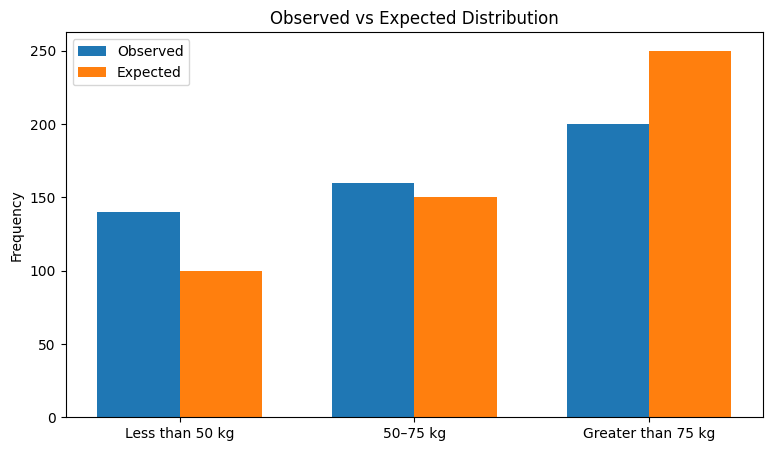

In [18]:
# Visual comparison of observed and expected frequencies

categories = [
    "Less than 50 kg",
    "50–75 kg",
    "Greater than 75 kg"
]

x = np.arange(len(categories))
width = 0.35

plt.figure(figsize=(9, 5))

plt.bar(x - width / 2, observed, width, label="Observed")
plt.bar(x + width / 2, expected, width, label="Expected")

plt.xticks(x, categories)
plt.ylabel("Frequency")
plt.title("Observed vs Expected Distribution")
plt.legend()

plt.show()

# 10. Complete Chi-Square Workflow

```text
Given categorical data
        ↓
Identify Observed values
        ↓
Determine Expected values
        ↓
State H₀ and H₁
        ↓
Choose significance α
        ↓
Calculate df = k − 1
        ↓
Find χ² critical value
        ↓
Calculate χ² statistic
        ↓
Compare calculated χ²
with critical χ²
       /       \
  Greater     Smaller
     ↓           ↓
Reject H₀    Fail to reject H₀
        ↓
Statistical Conclusion
```

# Key Takeaway

Remember:

$$
\boxed{
O\rightarrow E\rightarrow H\rightarrow df
\rightarrow\chi^2
\rightarrow\text{Compare}
\rightarrow\text{Conclusion}
}
$$

**Observed → Expected → Hypothesis → Degrees of Freedom → Chi-Square
Statistic → Compare → Conclusion**

### Core Idea

> **Chi-Square Goodness of Fit compares an observed categorical
> distribution with an expected/theoretical distribution.**